In [16]:
# Ham tong quat tinh tich phan nD chieu

import random as random
import numpy as np
import time


In [29]:
R =2
h =1

a_R  = -R/2
b_R = R/2

a_h = -h/2
b_h = h/2

N = 10000

k = 9*10**9

Q = 2e-9  #Coulomb

def hamso_tinhV(x, y, z, d):
    f = np.sqrt(x**2 + y**2 + (z-d)**2)
    return 1/f

def tich_phan_monte_carlo_3D(a_R, b_R, a_h, b_h, N, d):
    global k, Q
    S = 0
    for i in range(N):
        x = np.random.uniform(a_R, b_R)
        y = np.random.uniform(a_R, b_R)
        z = np.random.uniform(a_h, b_h)

        S += hamso_tinhV(x, y, z, d)

    the_tich = (b_R - a_R) * (b_R - a_R) * (b_h - a_h)

    tich_phan = the_tich * S / N

    rho = Q / the_tich

    dien_the = k * rho * tich_phan

    return dien_the

In [32]:
d_arr = np.linspace(1, 100, 100)

V_d_array = np.zeros(len(d_arr))
for i in range(len(d_arr)):
    V_d = tich_phan_monte_carlo_3D(a_R, b_R, a_h, b_h, N, d_arr[i])
    V_d_array[i] = V_d

In [37]:
with open(f"MC_1A_ketqua.dat", "w", encoding="utf-8") as file:
    file.write(f"# Ket qua tinh tich phan MC va thoi gian tinh cho truong hop tinh V theo d\n")
    file.write(f"#" * 80 + "\n" + "\n")
    file.write(f"# {'d':>30s} {'V':>30s}\n")
    for i in range(len(d_arr)):
        file.write(f"  {d_arr[i]:30.9f} {V_d_array[i]:30.9f}\n")

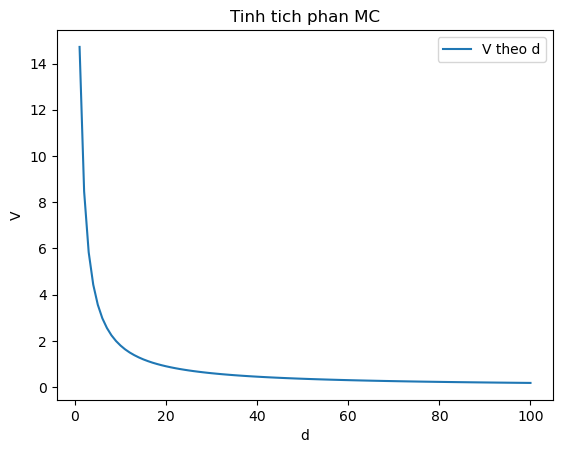

In [39]:
import matplotlib.pyplot as plt

d_load, V_load = np.loadtxt("MC_1A_ketqua.dat", comments="#", unpack=True)
plt.plot(d_load, V_load, label="V theo d")
plt.xlabel("d")
plt.ylabel("V")
plt.title("Tinh tich phan MC")
plt.legend()
plt.show()